In [1]:
import pandas as pd
import numpy as np

# =========================
# Load CSV file
# =========================
file_name = "dos_pred.csv"                                       # Output of the prediction map

df = pd.read_csv(file_name, header=None)

# =========================
# Extract energy values
# =========================
energies = df.iloc[0, 2:].astype(float).values

data = df.iloc[1:].reset_index(drop=True)

x_values = data.iloc[:, 0].astype(float).values
y_values = data.iloc[:, 1].astype(float).values

dos_matrix = data.iloc[:, 2:].astype(float).values

# =========================
# Interpolated band edge finder
# =========================
def interpolate_crossing(e1, e2, d1, d2, threshold):
    """
    Linear interpolation to find energy where DOS = threshold
    """

    # Avoid division by zero
    if d2 == d1:
        return e1

    return e1 + (threshold - d1) * (e2 - e1) / (d2 - d1)


def find_band_edges_interpolated(energies, dos, threshold=10):

    vbm = np.nan
    cbm = np.nan

    # ==================================================
    # Valence Band Edge (negative energy side)
    # Search from near 0 toward negative energies
    # ==================================================
    neg_indices = np.where(energies < 0)[0]

    for i in range(len(neg_indices) - 1, 0, -1):

        idx1 = neg_indices[i]
        idx2 = neg_indices[i - 1]

        d1 = dos[idx1]
        d2 = dos[idx2]

        # Check threshold crossing
        if (d1 < threshold and d2 >= threshold) or \
           (d1 >= threshold and d2 < threshold):

            e1 = energies[idx1]
            e2 = energies[idx2]

            vbm = interpolate_crossing(
                e1, e2, d1, d2, threshold
            )
            break

    # ==================================================
    # Conduction Band Edge (positive energy side)
    # Search from near 0 toward positive energies
    # ==================================================
    pos_indices = np.where(energies > 0)[0]

    for i in range(len(pos_indices) - 1):

        idx1 = pos_indices[i]
        idx2 = pos_indices[i + 1]

        d1 = dos[idx1]
        d2 = dos[idx2]

        # Check threshold crossing
        if (d1 < threshold and d2 >= threshold) or \
           (d1 >= threshold and d2 < threshold):

            e1 = energies[idx1]
            e2 = energies[idx2]

            cbm = interpolate_crossing(
                e1, e2, d1, d2, threshold
            )
            break

    return vbm, cbm


# =========================
# Process all rows
# =========================
results = []

for i in range(len(data)):

    dos = dos_matrix[i]

    vbm, cbm = find_band_edges_interpolated(
        energies,
        dos,
        threshold=10                             # The band edges will be considered where DOS ≥ 10 eV
    )

    if not np.isnan(vbm) and not np.isnan(cbm):
        band_gap = cbm - vbm
    else:
        band_gap = np.nan

    results.append([
        x_values[i],
        y_values[i],
        vbm,
        cbm,
        band_gap
    ])

# =========================
# Save results
# =========================
result_df = pd.DataFrame(
    results,
    columns=["x", "y", "VBM", "CBM", "BandGap"]
)

result_df.to_csv("band_edges_interpolated.csv", index=False)

print(result_df.head())

print("\nSaved as: band_edges_interpolated.csv")

     x    y       VBM       CBM   BandGap
0  1.0  1.0 -1.042726  0.742017  1.784742
1  2.0  1.0 -1.042346  0.742118  1.784464
2  3.0  1.0 -1.042754  0.742008  1.784762
3  4.0  1.0 -1.042900  0.741960  1.784860
4  5.0  1.0 -1.042900  0.741960  1.784860

Saved as: band_edges_interpolated.csv


## To plot

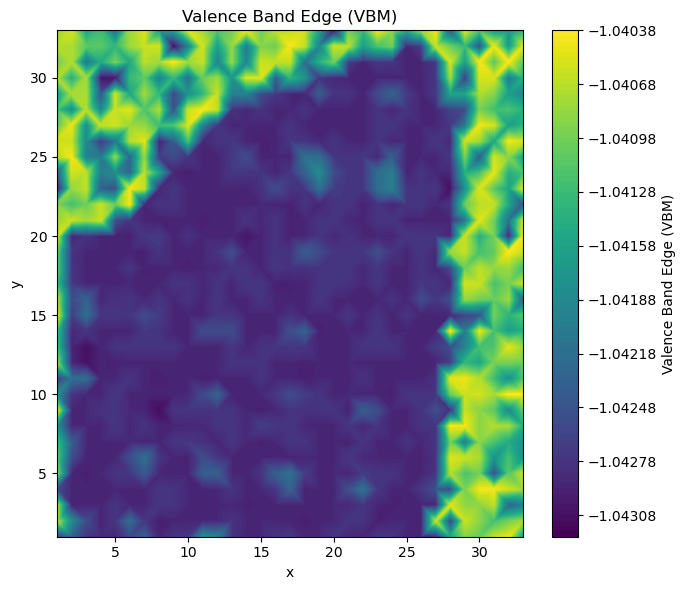

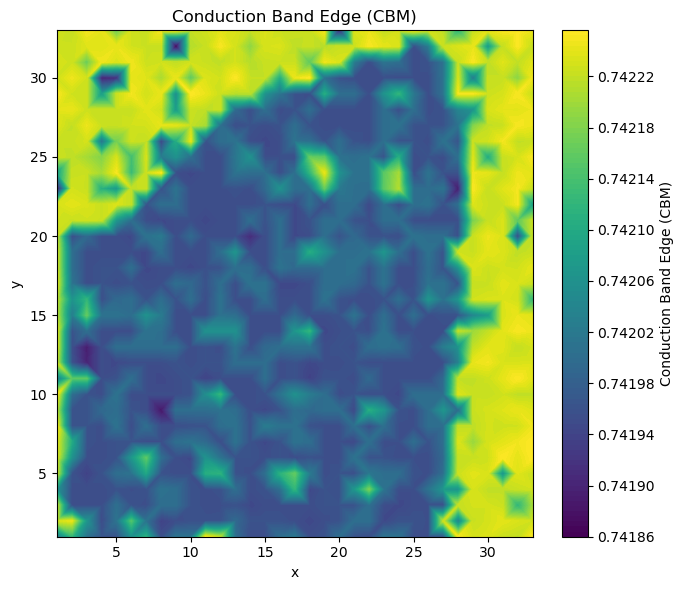

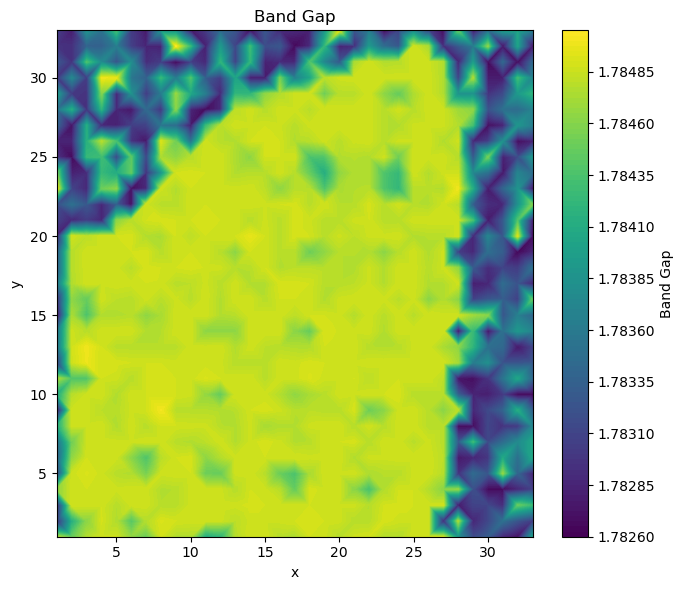

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load interpolated band edge data
# =========================
df = pd.read_csv("band_edges_interpolated.csv")

# =========================
# Extract columns
# =========================
x = df["x"].values
y = df["y"].values

vbm = df["VBM"].values
cbm = df["CBM"].values
bandgap = df["BandGap"].values

# =========================================================
# Function to make 2D colormap
# =========================================================
def plot_colormap(x, y, values, title, cmap="viridis"):

    plt.figure(figsize=(7, 6))

    # tricontourf works for scattered x,y points
    contour = plt.tricontourf(
        x,
        y,
        values,
        levels=100,
        cmap=cmap
    )

    plt.colorbar(contour, label=title)

    plt.xlabel("x")
    plt.ylabel("y")

    plt.title(title)

    plt.tight_layout()

    plt.show()


# =========================
# Plot VBM map
# =========================
plot_colormap(
    x,
    y,
    vbm,
    "Valence Band Edge (VBM)"
)

# =========================
# Plot CBM map
# =========================
plot_colormap(
    x,
    y,
    cbm,
    "Conduction Band Edge (CBM)"
)

# =========================
# Plot Band Gap map
# =========================
plot_colormap(
    x,
    y,
    bandgap,
    "Band Gap"
)